# 01 - Quickstart: Running a Transdermal Diffusion Simulation

This notebook walks through a **single simulation** of the V3 literature-calibrated
model to illustrate the core pipeline: load a YAML config, run the finite-difference
solver, and visualise the concentration field, flux curve, and summary scalars.

The V3 model includes three anatomical skin layers (stratum corneum, viable epidermis,
dermis) with literature-constrained diffusivities and correlated spatial heterogeneity.

## How This Notebook Fits The Thesis

This notebook establishes the simulation foundation used by the whole project.
Later notebooks reuse this same simulator output for:
- dataset generation and quality control,
- surrogate model training (black-box and hybrid PINN correction),
- final accuracy, robustness, and physics-diagnostic evaluation.

In other words, this notebook is the physics ground-truth source for the full thesis pipeline.

## Governing Model (PDE + BC/IC)

Let $C(z, x, t)$ be concentration in a 2D skin domain (depth $z$, lateral coordinate $x$):

$$\frac{\partial C}{\partial t} = \nabla \cdot \left(D(z, x) \nabla C\right) - k(z, x) C$$

- The left side $\partial C/\partial t$ is "how quickly concentration changes over time" at a point.
- The diffusion term $\nabla \cdot (D\nabla C)$ is spreading from high concentration to low concentration.
  If $D$ is larger, drug spreads faster.
- The $-kC$ term is local loss (clearance), so concentration can decrease even without leaving the domain.

Initial condition:

$$C(z, x, 0) = 0$$

Boundary conditions used in this project:
- Top boundary, on patch: $C(0, x, t) = C_d(t)$
- Top boundary, off patch: $\partial C/\partial z = 0$ (no flux)
- Bottom boundary (receptor sink): $C(H, x, t) = 0$
- Lateral boundaries: $\partial C/\partial x = 0$ (no flux)

For finite-dose runs (V3), donor concentration decays as:

$$C_d(t) = C_0 e^{-\lambda t}$$

For infinite-dose runs (V1/V2), $C_d(t)$ is constant.

Why these boundary conditions make sense physically:
- Patch region fixes the top concentration to mimic a drug reservoir touching skin.
- Off-patch top and lateral no-flux conditions avoid artificial side leakage.
- Bottom sink mimics rapid removal into receptor/systemic side.

### Symbol guide

- $C$: concentration field (mg/cm$^3$)
- $D$: diffusion coefficient (cm$^2$/s)
- $k$: first-order clearance rate (s$^{-1}$)
- $C_0$: initial donor concentration
- $\lambda$: donor depletion rate in finite-dose runs
- $H$: full skin depth in the simulation domain


## Numerical Scheme And Stability

The solver uses explicit finite-difference time stepping with a conservative variable-diffusivity operator:

$$C^{n+1} = C^n + \Delta t \left[\nabla \cdot (D \nabla C) - kC\right]^n$$

The conservative flux form is important for layered media so interface transport remains physically consistent when $D$ changes sharply between layers.

Practical stability constraints checked in the run metadata:
- diffusion-limited step size: $\Delta t = \mathcal{O}(\Delta x^2 / D_{\max})$
- reaction-limited step size: $\Delta t = \mathcal{O}(1/k_{\max})$

### Breakdown

- "Explicit" means the next step $C^{n+1}$ is computed directly from the current step $C^n$.
  This is simple and fast, but only stable when $\Delta t$ is small enough.
- The conservative form helps preserve physically meaningful transport across layer boundaries,
  especially where diffusivity jumps by orders of magnitude (for example SC to dermis).
- If $\Delta t$ is too large, explicit schemes can become unstable (oscillatory or negative values),
  so the two limits above are checked before/after runs.

### Why this is suitable here

- The grid and timestep are chosen so the method remains stable.
- The approach is computationally efficient for generating many synthetic runs.
- Verification in Notebook 03 then checks that this discretization is numerically trustworthy.


## Literature Basis For Modelling Choices

This notebook follows modelling choices supported by literature and used throughout the project:
- Fickian layered transport with barrier-dominant stratum corneum behavior (Prausnitz and Langer, 2008).
- Human-skin lidocaine permeability and lag-time targets for calibration (Adamiak-Giera et al., 2023).
- Diffusion-equation benchmark framing and finite-slab reference theory (Crank, 1975).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

print('Setup complete OK')

Setup complete OK


## 1 - Load config & run simulation

We load the V3 literature-calibrated config which simulates 24 hours of transdermal
drug diffusion through a layered skin model.

In [2]:
cfg = load_config('configs/sim/v3_layers_literature.yaml')
C_snap, t_save, D_field, k_field, patch_mask, diag, metrics, stab = run_simulation(cfg)

print(f'Grid shape: {C_snap.shape[1:]} (depth x radial)')
print(f'Snapshots: {C_snap.shape[0]} time points over {t_save[-1]/3600:.0f} h')
print(f'D range: [{D_field.min():.2e}, {D_field.max():.2e}] cm^2/s')
print(f'Layers: SC (rows 0-0), VE (rows 1-9), Dermis (rows 10-63)')
print(f'Stability info: {stab}')

simulate: 100%|██████████| 432001/432001 [00:29<00:00, 14882.51it/s]


Grid shape: (64, 64) (depth x radial)
Snapshots: 1441 time points over 24 h
D range: [1.16e-09, 2.32e-07] cm^2/s
Layers: SC (rows 0-0), VE (rows 1-9), Dermis (rows 10-63)
Stability info: {'Dmax': 2.32348986647243e-07, 'dt_diff_max': 0.6886193148882344, 'kmax': 0.0, 'dt_react_max': None}


## 2 - Concentration heatmaps

Snapshots at selected times show the drug front propagating from the patch (top)
through the stratum corneum, viable epidermis, and dermis.

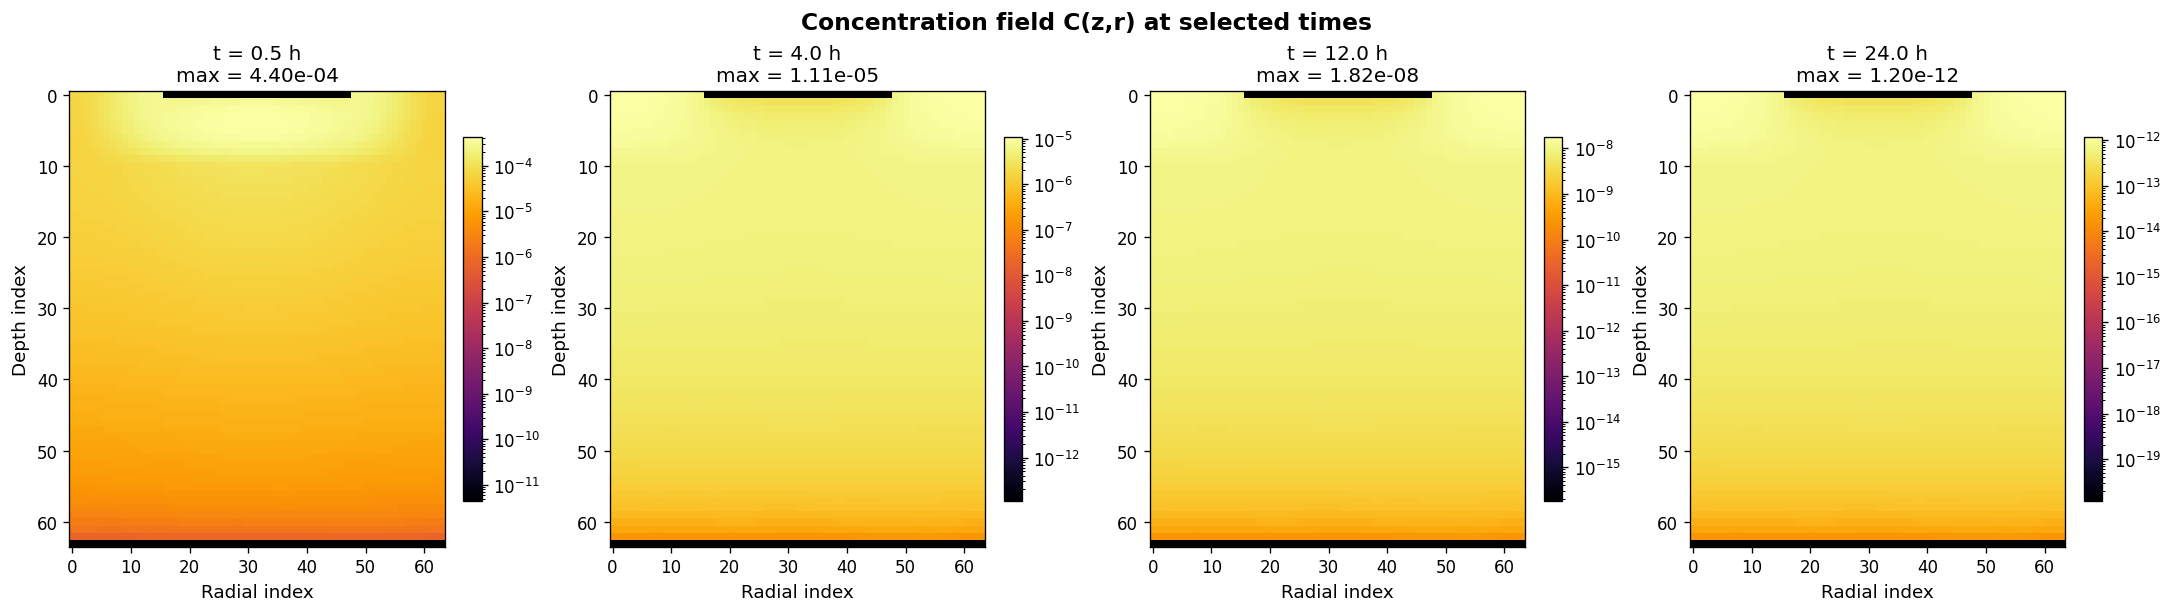

In [3]:
# Pick 4 time snapshots: early, mid, late, end
t_hours = t_save / 3600
snap_times_h = [0.5, 4, 12, 24]
snap_idx = [np.argmin(np.abs(t_hours - t)) for t in snap_times_h]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)
fig.suptitle('Concentration field C(z,r) at selected times',
             fontsize=14, fontweight='bold')

for ax, idx in zip(axes, snap_idx):
    data = C_snap[idx]
    # Per-panel normalisation: floor at 1e-8 * panel max to show spatial structure
    panel_max = data.max()
    panel_floor = max(panel_max * 1e-8, 1e-20)
    data_plot = np.where(data > panel_floor, data, panel_floor)
    im = ax.imshow(data_plot, aspect='auto', origin='upper',
                   norm=LogNorm(vmin=panel_floor, vmax=panel_max),
                   cmap='inferno')
    ax.set_title(f't = {t_hours[idx]:.1f} h\nmax = {panel_max:.2e}')
    ax.set_xlabel('Radial index')
    ax.set_ylabel('Depth index')
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.show()

**Figure 2.1 — Concentration heatmaps at 0.5, 4, 12 and 24 hours.**
Each panel uses its own log-normalised colour scale (note the different colour-bar ranges).

- **t = 0.5 h** — Drug is concentrated directly beneath the patch; peak ≈ 4.4 × 10⁻⁴ mg/cm³.
- **t = 4 h** — Diffusion front has penetrated into the dermis; peak drops by ~40×.
- **t = 12 h** — Donor substantially depleted under the time-decay boundary; concentrations fall by several more orders of magnitude.
- **t = 24 h** — Near-complete depletion; overall concentration five to eight orders below early peak.

The lateral spread outside the patch edges is visible as the concentration gradient fans outward.

## 3 -- Depth profile at patch centre

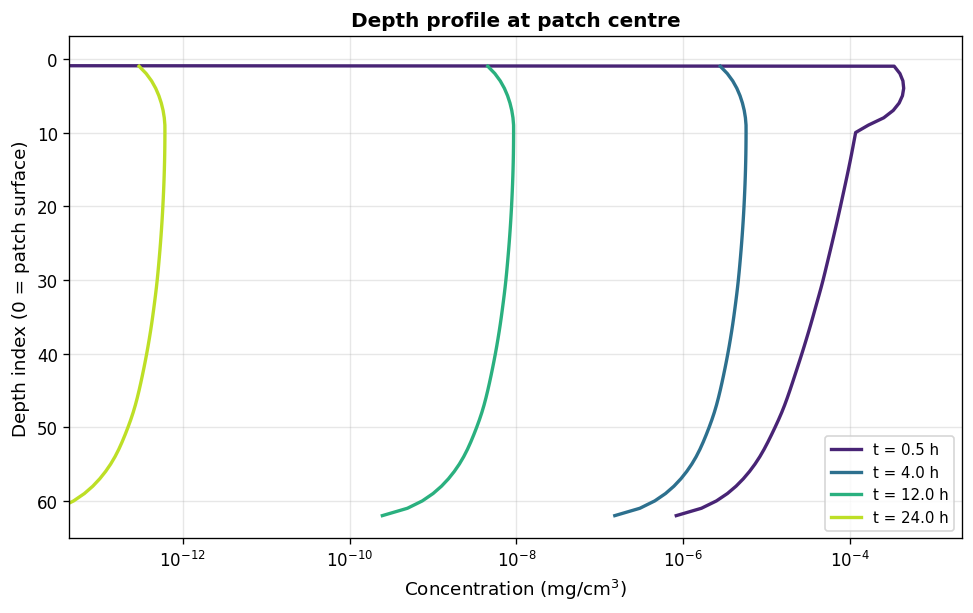

In [4]:
r_mid = C_snap.shape[2] // 2
colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(snap_idx)))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

global_max = 0.0
for idx, c in zip(snap_idx, colours):
    profile = C_snap[idx, :, r_mid]
    # Replace negligible values with NaN so they don't appear on log scale
    profile_plot = np.where(profile > 0, profile, np.nan)
    ax.plot(profile_plot, range(len(profile)), color=c,
            label=f't = {t_hours[idx]:.1f} h', linewidth=2)
    pmax = np.nanmax(profile_plot)
    if pmax > global_max:
        global_max = pmax

# Focus x-axis on physically meaningful range (clip numerical noise)
ax.set_xscale('log')
ax.set_xlim(left=global_max * 1e-10, right=global_max * 5)
ax.set_xlabel('Concentration (mg/cm$^3$)')
ax.set_ylabel('Depth index (0 = patch surface)')
ax.invert_yaxis()
ax.set_title('Depth profile at patch centre', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Figure 3.1 — Concentration vs. depth at the patch centre (log scale).**
Each curve is a vertical slice through the centre of the patch at a different time:

- **t = 0.5 h** (purple) — Highest concentration (~10⁻⁴ mg/cm³), confined to the top ~10 rows (SC + upper VE).
- **t = 4 h** (blue) — Front has reached the bottom of the domain (~row 55) but with reduced magnitude.
- **t = 12 h** (teal) — Donor has decayed; overall concentration drops further.
- **t = 24 h** (yellow) — Lowest concentrations across the full depth.

The steep gradient in the top rows reflects the low diffusivity of the stratum corneum acting as the rate-limiting barrier.

## 4 -- Flux curve and scalar summary

### Flux And Scalar Definitions Used In This Notebook

Bottom-boundary flux is computed from the concentration gradient:

$$J(t) = -D \left.\frac{\partial C}{\partial z}\right|_{z=H}$$

Reported scalar endpoints:
- $J_{\mathrm{peak}} = \max_t J(t)$
- $t_{\mathrm{peak}} = \arg\max_t J(t)$
- $M_{\mathrm{delivered,24h}} = \int_0^{24h} J(t)\,dt$
- $P = J_{\mathrm{ss}}/C_0$ (mainly meaningful in near-steady or infinite-dose settings)
- $T_{\mathrm{lag}}$ from linear extrapolation of cumulative delivered mass

For finite-dose V3 runs, $J_{\mathrm{ss}}$ and $P$ are interpreted as tail summaries rather than strict steady-state constants.

### Breakdown

- The minus sign in $J(t)$ just reflects direction: drug moves from skin toward the receptor side.
- Larger boundary gradient means larger flux (faster delivery rate).

What each scalar tells you:
- $J_{\mathrm{peak}}$: maximum delivery rate achieved.
- $t_{\mathrm{peak}}$: when that maximum happens.
- $M_{\mathrm{delivered,24h}}$: total amount delivered over 24 h (area under flux curve).
- $P$: permeability-style summary linking flux to donor strength.
- $T_{\mathrm{lag}}$: onset delay before substantial permeation.

These are useful because they compress full curves into clinically interpretable endpoints
while still keeping the full $J(t)$ curve for detailed comparison.


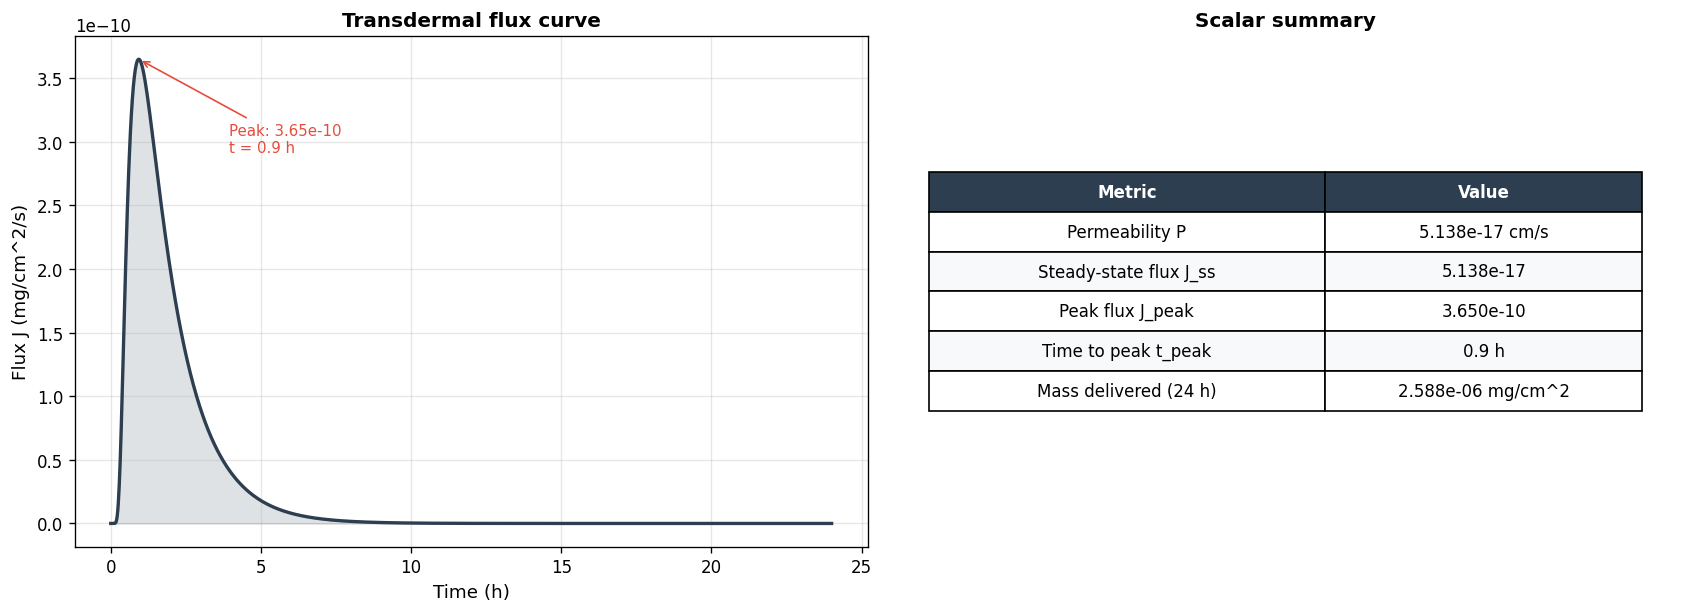

In [5]:
J = np.array(metrics['J'])
t_h = np.array(metrics['t']) / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# --- Flux curve ---
ax = axes[0]
ax.plot(t_h, J, color='#2c3e50', linewidth=2)
ax.fill_between(t_h, J, alpha=0.15, color='#2c3e50')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Flux J (mg/cm^2/s)')
ax.set_title('Transdermal flux curve', fontweight='bold')
ax.grid(alpha=0.3)

# Mark peak
j_peak_idx = np.argmax(J)
ax.annotate(f'Peak: {J[j_peak_idx]:.2e}\nt = {t_h[j_peak_idx]:.1f} h',
            xy=(t_h[j_peak_idx], J[j_peak_idx]),
            xytext=(t_h[j_peak_idx] + 3, J[j_peak_idx] * 0.8),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=9, color='#e74c3c')

# --- Scalar summary ---
ax = axes[1]
ax.axis('off')
scalar_data = [
    ['Metric', 'Value'],
    ['Permeability P', f'{metrics["P"]:.3e} cm/s'],
    ['Steady-state flux J_ss', f'{metrics["J_ss"]:.3e}'],
    ['Peak flux J_peak', f'{metrics["J_peak"]:.3e}'],
    ['Time to peak t_peak', f'{metrics["t_peak"]/3600:.1f} h'],
    ['Mass delivered (24 h)', f'{metrics["M_delivered_24h"]:.3e} mg/cm^2'],
]
table = ax.table(cellText=scalar_data[1:], colLabels=scalar_data[0],
                 cellLoc='center', loc='center',
                 colWidths=[0.5, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Header style
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else 'white')

ax.set_title('Scalar summary', fontweight='bold')
plt.show()

**Figure 4.1 -- Transdermal flux curve and scalar summary.**

*Left panel:* The flux *J(t)* through the bottom boundary (dermis-to-systemic interface)
over the full 24-hour simulation.  The curve rises sharply to a peak of
**3.65 x 10^-10 mg/cm^2/s at t = 0.9 h**, then decays as the donor reservoir depletes
under the time-decay boundary condition.  The shaded area under the curve is
proportional to the total mass delivered.

*Right panel:* Key pharmacokinetic scalars extracted from the simulation --
permeability *P*, steady-state flux *J_ss*, peak flux *J_peak* and its timing *t_peak*,
and the cumulative mass delivered over 24 hours.  These five scalars are the
prediction targets for the downstream ML surrogate models.

## 5 -- Diffusivity field

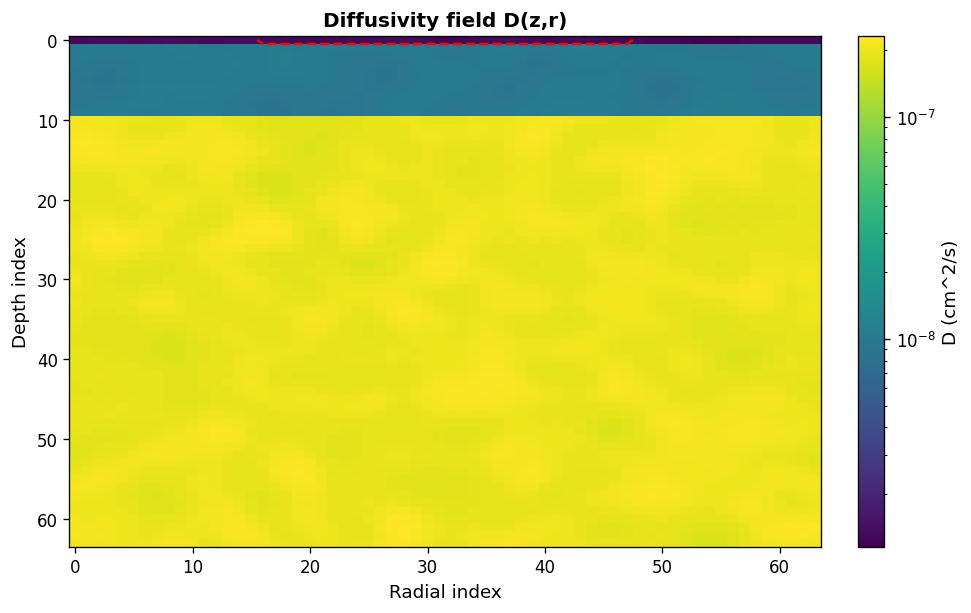

In [6]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

im = ax.imshow(D_field, aspect='auto', origin='upper',
               norm=LogNorm(), cmap='viridis')
fig.colorbar(im, ax=ax, label='D (cm^2/s)')
ax.set_xlabel('Radial index')
ax.set_ylabel('Depth index')
ax.set_title('Diffusivity field D(z,r)', fontweight='bold')

# Overlay patch mask outline
if patch_mask is not None:
    ax.contour(patch_mask.astype(float), levels=[0.5],
               colors='red', linewidths=1.5, linestyles='--')

plt.show()

**Figure 5.1 -- Spatially-varying diffusivity field D(z, r).**
The heatmap shows the diffusion coefficient assigned to each grid cell on a log colour scale.
Three distinct skin layers are visible:
- **Stratum corneum** (top strip, dark purple, row 0): *D* ~ 1.3 x 10^-9 cm^2/s -- the main barrier to drug transport.
- **Viable epidermis** (teal band, rows 1-9): *D* ~ 1 x 10^-8 cm^2/s -- roughly an order of magnitude faster.
- **Dermis** (yellow region, rows 10-63): *D* ~ 2 x 10^-7 cm^2/s -- the most permeable layer, about 150x faster than the SC.

The subtle spatial texture within each layer is the correlated heterogeneity (*sigma* = 0.05)
that makes each simulation stochastically unique.
The **red dashed contour** outlines the patch footprint on the skin surface.

## References For Notebook 01

1. Crank, J. *The Mathematics of Diffusion* (2nd ed.). Oxford University Press, 1975.
2. Prausnitz, M. R., and Langer, R. Transdermal drug delivery. *Nature Biotechnology* 26, 1261-1268 (2008).
3. Adamiak-Giera, U. et al. *Frontiers in Pharmacology* 14:1157977 (2023). doi:10.3389/fphar.2023.1157977

---

### Summary

This quickstart demonstrated the full simulation pipeline:
1. **Config** -- YAML specifies geometry, skin layers, drug properties, and solver parameters
2. **Solver** -- 2-D finite-difference with explicit time integration
3. **Outputs** -- concentration snapshots, flux curve, and five PK-relevant scalars

The V3 model produces physically realistic diffusion patterns with drug penetrating
through the stratum corneum barrier before spreading into deeper tissue.

Next: [02 -- Model regimes](02_model_regimes_v1_v2_v3.ipynb) compares V1, V2, and V3.